In [30]:
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np

import scipy.signal as signal
import soundfile as sf
from pathlib import Path

# Drum

In [31]:
FS = 44100

OUTPUT_DIR = Path('output')
assert OUTPUT_DIR.exists(), "Output directory does not exist."

LOWPASS = 'lowpass'
HIGHPASS = 'highpass'

In [32]:
import numpy as np

def gen_drum_type1(
    dur, 
    freq0, 
    pitch_decay_level=0.01, 
    amp_decay_level=0.01, 
    FS=48000,
    start_phase=0.0
):
    # guards
    pitch_decay_level = float(np.clip(pitch_decay_level, 1e-6, 0.999999))
    amp_decay_level   = float(np.clip(amp_decay_level,   1e-6, 0.999999))
    n = int(dur * FS)

    # exponential envelopes (start=1 → end=level over n samples)
    t = np.linspace(0.0, 1, n, endpoint=False)
    pitch_env = np.exp(np.log(pitch_decay_level) * t)
    amp_env   = np.exp(np.log(amp_decay_level)   * t)

    # instantaneous frequency sweeps downward
    freq = freq0 * pitch_env
    # optional anti-alias clamp
    freq = np.minimum(freq, 0.45 * FS)  # keep below Nyquist a bit

    # integrate 2π f / FS to get phase; wrap to avoid drift
    phase_inc = 2.0 * np.pi * freq / FS
    phase = np.cumsum(phase_inc) + start_phase
    phase = np.mod(phase, 2.0 * np.pi)

    out = amp_env * np.sin(phase)

    # optional soft clip to tame transients
    # out = np.tanh(out * 1.5)
    return out

In [33]:
from scipy.signal import sosfilt

def _biquad_sos_lowpass(cutoff, Q, FS):
    # RBJ low-pass
    w0 = 2.0 * np.pi * cutoff / FS
    cw = np.cos(w0)
    sw = np.sin(w0)
    alpha = sw / (2.0 * Q)

    b0 = (1 - cw) / 2
    b1 =  1 - cw
    b2 = (1 - cw) / 2
    a0 =  1 + alpha
    a1 = -2 * cw
    a2 =  1 - alpha

    # normalize and convert to SOS: [b0 b1 b2 a0 a1 a2] → [[b0 b1 b2 a0 a1 a2]]
    b0 /= a0; b1 /= a0; b2 /= a0
    a1 /= a0; a2 /= a0
    return np.array([[b0, b1, b2, 1, a1, a2]])

def _biquad_sos_bandpass(cutoff, Q, FS):
    # RBJ band-pass (constant skirt gain)
    w0 = 2.0 * np.pi * cutoff / FS
    cw = np.cos(w0)
    sw = np.sin(w0)
    alpha = sw / (2.0 * Q)

    b0 =  alpha
    b1 =  0.0
    b2 = -alpha
    a0 =  1 + alpha
    a1 = -2 * cw
    a2 =  1 - alpha

    b0 /= a0; b1 /= a0; b2 /= a0
    a1 /= a0; a2 /= a0
    return np.array([[b0, b1, b2, 1, a1, a2]])

def gen_drum_type2(
    dur,
    cut_off_freq,
    Q=0.7,
    amp_decay_level=0.01,
    FS=48000,
    mode="bp"  # "bp" for snare/hat-ish, "lp" for kick-ish thump
):
    n = int(dur * FS)
    amp_decay_level = float(np.clip(amp_decay_level, 1e-6, 0.999999))
    Q = float(max(Q, 1e-4))
    cut_off_freq = float(np.clip(cut_off_freq, 10.0, 0.49 * FS))

    # envelope
    t = np.linspace(0.0, 1, n, endpoint=False)
    amp_env = np.exp(np.log(amp_decay_level) * t)

    # excitation (white noise burst)
    x = (np.random.rand(n) - 0.5)

    # choose filter
    if mode.lower() == "lp":
        sos = _biquad_sos_lowpass(cut_off_freq, Q, FS)
    else:
        sos = _biquad_sos_bandpass(cut_off_freq, Q, FS)

    y = sosfilt(sos, x)
    y *= amp_env

    # optional normalization (keep some headroom)
    peak = np.max(np.abs(y)) + 1e-12
    y = 0.9 * y / peak
    return y

In [34]:
kick = gen_drum_type1(0.20, freq0=160, pitch_decay_level=0.02, amp_decay_level=0.008, FS=FS)
ipd.Audio(kick, rate=FS)

In [35]:
snare = gen_drum_type2(0.20, cut_off_freq=1800, Q=0.8, amp_decay_level=0.02, FS=FS)
ipd.Audio(snare, rate=FS)

In [36]:
hihat = gen_drum_type2(0.06, cut_off_freq=8000, Q=0.7, amp_decay_level=0.05, FS=FS)
ipd.Audio(hihat, rate=FS)

# Generate My Own Drum Sound

In [37]:
BPM = 120.0
SPB = 60.0 / BPM
BARS = 8

In [38]:
duration_sec = 16.0
n_samples = int(duration_sec * FS)
mix = np.zeros(n_samples, dtype=np.float32)

BPM = 120
SPB = 60.0 / BPM
beats_total = int(duration_sec / SPB)


def add_one_shot(buf, start_idx, one_shot, gain=1):
    end_idx = start_idx + len(one_shot)
    if start_idx >= len(buf):
        return
    end_idx = min(end_idx, len(buf))
    length = end_idx - start_idx
    buf[start_idx:end_idx] += gain * one_shot[:length].astype(buf.dtype, copy=False)

for b in range(beats_total):
    t_sec = b * SPB
    i = int(t_sec * FS)

    # Kick and snare pattern (basic 4/4)
    if b % 4 in (0, 2):
        add_one_shot(mix, i, kick, gain=0.9)
    if b % 4 in (1, 3):
        add_one_shot(mix, i, snare, gain=0.8)

    # Hi-hats (8th notes), double hit every 4th bar
    i_hat = int((b * SPB) * FS)
    add_one_shot(mix, i_hat, hihat, gain=0.4)
    i_hat2 = int((b * SPB + SPB * 0.5) * FS)
    add_one_shot(mix, i_hat2, hihat, gain=0.35)

    # Every 8th beat, add an extra “ghost” hi-hat slightly ofFSet
    if b % 8 == 7:
        add_one_shot(mix, int((b * SPB + SPB * 0.75) * FS), hihat, gain=0.25)

# Ending fill (last 2 seconds, quick tom-like hits)
fill_start = int((duration_sec - 2.0) * FS)
for j in range(8):
    t = fill_start + int(j * 0.25 * FS)
    tom = gen_drum_type1(0.15, freq0=180 + 40*j, pitch_decay_level=0.03, amp_decay_level=0.01, FS=FS)
    add_one_shot(mix, t, tom, gain=0.6 - 0.05*j)

# Normalize
# sf.write(OUTPUT_DIR / "result_5_tom_like_hit_at_the_end.wav", mix, FS)
ipd.Audio(mix, rate=FS)

# Melody

In [ ]:
import numpy as np
from scipy.signal import butter, lfilter, resample_poly
import IPython.display as ipd

def adsr(n, fs, a=0.01, d=0.08, s=0.6, r=0.12):
    A = int(a*fs); D = int(d*fs); R = int(r*fs)
    S = max(0, n - (A + D + R))
    env = np.concatenate([
        np.linspace(0, 1, max(A,1), False),
        np.linspace(1, s, max(D,1), False),
        np.full(S, s),
        np.linspace(s, 0, max(R,1), False),
    ])
    if len(env) < n: env = np.pad(env, (0, n-len(env)), mode='edge')
    return env[:n].astype(np.float32)

def midi_to_hz(m): 
    return 440.0 * (2.0 ** ((m - 69)/12.0))

def osc_wave(kind, phase):
    if kind == 'sine':
        return np.sin(phase)
    elif kind == 'saw':
        return 2.0 * (phase/(2*np.pi) % 1.0) - 1.0
    elif kind == 'square':
        return np.sign(np.sin(phase))
    elif kind == 'tri':
        return 2.0*np.abs(2.0*((phase/(2*np.pi))%1.0) - 1.0) - 1.0
    else:
        return np.sin(phase)

def biquad_filter(x, cutoff, q, mode, fs):
    Wn = np.clip(cutoff/(fs*0.5), 1e-4, 0.99)
    btype = {'lp':'low', 'hp':'high', 'bp':'band'}.get(mode, 'low')
    if btype == 'band':
        bw = cutoff / max(q, 1e-3)
        lo = np.clip((cutoff-bw/2)/(fs*0.5), 1e-4, 0.99)
        hi = np.clip((cutoff+bw/2)/(fs*0.5), lo+1e-4, 0.999)
        b, a = butter(2, [lo, hi], btype='bandpass')
    else:
        b, a = butter(2, Wn, btype=btype)
    return lfilter(b, a, x).astype(np.float32)

def one_pole_lp_var(x, fc_env, fs):
    y = np.zeros_like(x, dtype=np.float32); z = 0.0
    two_pi = 6.283185307179586
    for i in range(len(x)):
        fc = float(np.clip(fc_env[i], 30.0, 0.49*fs))
        a = (two_pi*fc) / (two_pi*fc + fs)
        z += a * (x[i] - z)
        y[i] = z
    return y

def delay_feedback(x, fs, delay_s=0.25, fb=0.25, wet=0.18):
    d = max(1, int(delay_s*fs))
    out = x.astype(np.float32).copy()
    g = float(np.clip(fb, 0.0, 0.85))  # keep stable
    for i in range(d, len(out)):
        out[i] += g*out[i-d]
    return ((1-wet)*x + wet*out).astype(np.float32)

def schroeder_reverb(x, fs, wet=0.12):
    x = np.asarray(x)
    if x.ndim != 1:
        x = x.reshape(-1)
    N = x.shape[0]

    xin = np.nan_to_num(x.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    xin *= 0.5

    def comb(sig, delay_s, g):
        D = max(1, int(delay_s * fs))
        g = float(np.clip(g, 0.0, 0.85))  # keep comfortably < 1
        buf = np.zeros(D, dtype=np.float64)
        y = np.zeros_like(sig, dtype=np.float64)
        idx = 0
        for n in range(N):
            # Feedback comb: y[n] = buf[n] ; buf[n] = x[n] + g * y[n]
            yn = buf[idx]
            buf[idx] = sig[n] + g * yn
            y[n] = yn
            idx += 1
            if idx == D: idx = 0
        return y

    combs = [
        comb(xin, 0.0297, 0.78),
        comb(xin, 0.0371, 0.80),
        comb(xin, 0.0411, 0.76),
    ]
    s = (combs[0] + combs[1] + combs[2]) / 3.0

    def allpass(sig, delay_s, g=0.5):
        D = max(1, int(delay_s * fs))
        g = float(np.clip(g, 0.0, 0.7))   # safe margin
        buf = np.zeros(D, dtype=np.float64)
        y = np.zeros_like(sig, dtype=np.float64)
        idx = 0
        for n in range(N):
            xn = sig[n]
            v = xn - g * buf[idx]
            yn = buf[idx] + g * v
            buf[idx] = v
            y[n] = yn
            idx += 1
            if idx == D: idx = 0
        return y

    s = allpass(s, 0.0050, 0.65)
    s = allpass(s, 0.0017, 0.65)

    wet = float(np.clip(wet, 0.0, 0.9))
    out = (1.0 - wet) * xin + wet * s
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

    out = np.tanh(out)
    out = out.astype(np.float32)
    return out

def synthesize_melody_tone(
    notes_midi, durs_sec,
    fs=44100,
    # Oscillators
    osc_type='saw', osc_count=None, detune_cents=None,
    # FM
    fm_enable=False, fm_ratio=None, fm_beta=None,
    # Filter
    filt_enable=False, filt_type=None, filt_cutoff_hz=None, filt_q=None,
    filt_env_amt=None, filt_env=None, cutoff_tracks_pitch=None,
    # Amp envelope
    amp_env=None,
    # Mod & FX
    vibrato_hz=None, vibrato_depth_semitones=None, glide_time=None,
    wah_enable=False, wah_lfo_hz=None, wah_depth_oct=None,
    delay_enable=False, delay_time=None, delay_fb=None, delay_wet=None,
    reverb_wet=None,
):
    
    # --- Helper defaults ---
    def set_default(val, default):
        return default if val is None else val

    # --- Resolve defaults only when needed ---
    osc_count           = set_default(osc_count, 2)
    detune_cents        = set_default(detune_cents, 7.0)

    fm_enable           = set_default(fm_enable, False)
    fm_ratio            = set_default(fm_ratio, 2.0)
    fm_beta             = set_default(fm_beta, 4.0)

    filt_enable         = set_default(filt_enable, True)
    filt_type           = set_default(filt_type, 'lp')
    filt_cutoff_hz      = set_default(filt_cutoff_hz, 1800.0)
    filt_q              = set_default(filt_q, 0.707)
    filt_env_amt        = set_default(filt_env_amt, 0.0)
    filt_env            = set_default(filt_env, (0.005, 0.05, 0.4, 0.12))
    cutoff_tracks_pitch = set_default(cutoff_tracks_pitch, True)

    amp_env             = set_default(amp_env, (0.005, 0.06, 0.6, 0.12))

    vibrato_hz          = set_default(vibrato_hz, 5.5)
    vibrato_depth_semitones = set_default(vibrato_depth_semitones, 0.03)
    glide_time          = set_default(glide_time, 0.02)

    wah_enable          = set_default(wah_enable, False)
    wah_lfo_hz          = set_default(wah_lfo_hz, 1.2)
    wah_depth_oct       = set_default(wah_depth_oct, 1.0)

    delay_enable        = set_default(delay_enable, True)
    delay_time          = set_default(delay_time, 0.25)
    delay_fb            = set_default(delay_fb, 0.25)
    delay_wet           = set_default(delay_wet, 0.16)
    reverb_wet          = set_default(reverb_wet, 0.12)
    
    # --- Synthesis core ---
    N_total = int(sum(durs_sec)*fs + 1)
    out = np.zeros(N_total, dtype=np.float32)
    last_freq = None
    cents = np.array([0] if osc_count==1 else np.linspace(-detune_cents, detune_cents, osc_count))
    detune_ratio = 2.0 ** (cents/1200.0)

    t_cursor = 0
    for midi, dur in zip(notes_midi, durs_sec):
        ns = int(max(1e-4, dur)*fs)
        if midi is None:
            t_cursor += ns
            continue

        base = midi_to_hz(midi)
        t = np.arange(ns)/fs
        
        vib = 2.0**((vibrato_depth_semitones*np.sin(2*np.pi*vibrato_hz*t))/12.0)

        if last_freq is None:
            f_inst = base * vib
        else:
            g = min(int(glide_time*fs), ns)
            glide_curve = np.concatenate([
                np.linspace(last_freq, base, g, endpoint=False),
                np.full(ns-g, base)
            ])
            f_inst = glide_curve * vib
        last_freq = base

        mod = fm_beta * np.sin(2*np.pi*fm_ratio*np.cumsum(f_inst)/fs) if fm_enable else 0.0

        sig = np.zeros(ns, dtype=np.float32)
        for r in detune_ratio:
            f = f_inst * r
            phase_inc = 2*np.pi*f/fs
            phase = np.cumsum(phase_inc) + mod
            sig += osc_wave(osc_type, phase).astype(np.float32)
        sig /= float(osc_count)

        if filt_enable:
            fa, fd, fsus, fr = filt_env
            fenv = adsr(ns, fs, fa, fd, fsus, fr)
            fc = np.full(ns, filt_cutoff_hz, dtype=np.float32)
            if cutoff_tracks_pitch:
                fc *= (f_inst / 440.0)
            if filt_env_amt > 1e-6:
                fc *= (1.0 + filt_env_amt * fenv)
            sig = one_pole_lp_var(sig, np.clip(fc, 30.0, 0.49*fs), fs)
            sig = biquad_filter(sig, float(np.mean(np.clip(fc, 30.0, 0.49*fs))), max(filt_q, 1e-3), filt_type, fs)

        aa, ad, asus, ar = amp_env
        sig *= adsr(ns, fs, aa, ad, asus, ar)

        if wah_enable:
            center = np.clip(base * (2.0**(wah_depth_oct*np.sin(2*np.pi*wah_lfo_hz*t))), 80.0, fs*0.45)
            sig = one_pole_lp_var(sig, np.clip(center*1.5, 80.0, fs*0.45), fs)
            sig = biquad_filter(sig, float(np.mean(center)), 2.0, 'bp', fs)

        end = min(N_total, t_cursor + ns)
        out[t_cursor:end] += sig[:end - t_cursor]
        t_cursor += ns

    if delay_enable:
        out = delay_feedback(out, fs, delay_time, delay_fb, delay_wet)
    if reverb_wet > 1e-6:
        out = schroeder_reverb(out, fs, wet=reverb_wet)

    peak = float(np.max(np.abs(out)) + 1e-12)
    out = (0.98/peak) * out
    return out.astype(np.float32)


In [151]:
notes_and_duration = [
    ("미", 2), ("파", 1), ("레", 1),
    ("솔", 2), (None, 0.5), ("도-", 0.5), ("시", 0.5), ("도-", 0.5),
    ("라", 2.5), ("도-", 0.5), ("시", 0.5), ("도-", 0.5),
    ("솔", 3), (None, 1),
    ("도", 1.5), ("레", 0.5), ("미", 1), ("도", 1),
    ("라", 2.5), ("라", 0.5), ("파", 0.5), ("레", 0.5),
    ("시_", 2), ("시_", 0.5), ("도", 0.25), ("시_", 0.25), ("라_", 0.5), ("시_", 0.5),
    ("도", 4)
]
note_dict = {"라_": 57, "시_": 59,
             "도":60, "레":62, "미":64, "파":65, "솔":67, "라":69, "시":71,
             "도-": 72}

# Convert notes_and_duration to notes_midi and durs_sec arrays
beat_s = 60 / BPM
notes_midi = []
durs_sec = []
for note, dur in notes_and_duration:
    if note is None:
        notes_midi.append(None)
    else:
        notes_midi.append(note_dict[note])
    durs_sec.append(dur * beat_s)

In [152]:
angelic = synthesize_melody_tone(
    notes_midi, durs_sec, fs=44100,
    osc_type='saw', osc_count=5, detune_cents=5.0,
    fm_enable=True, fm_ratio=1.0, fm_beta=0.5,
    filt_enable=True, filt_type='lp', filt_cutoff_hz=2200.0, filt_q=0.7,
    filt_env_amt=0.08, filt_env=(0.05, 0.35, 0.70, 1.20),
    cutoff_tracks_pitch=False,
    amp_env=(0.18, 0.50, 0.85, 1.50),
    # vibrato_hz=5.2, vibrato_depth_semitones=0.025, glide_time=0.020,
    # delay_enable=True, delay_time=0.045, delay_fb=0.22, delay_wet=0.10,
    # reverb_wet=0.38,
)
# sf.write(OUTPUT_DIR / "result_angelic.wav", angelic, FS)
ipd.Audio(angelic, rate=FS)

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

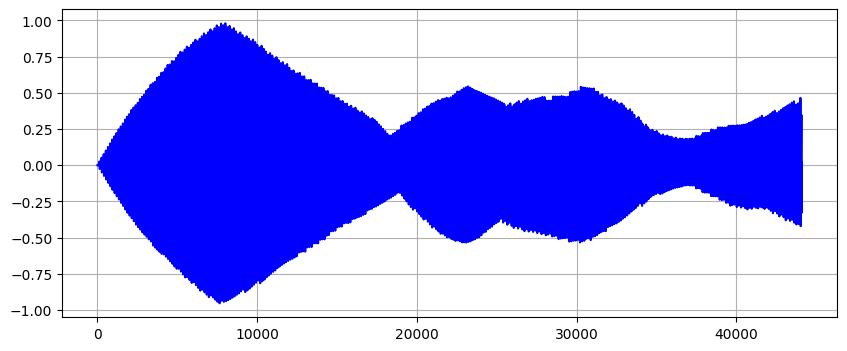

In [149]:
tmp_note = [64]
tmp_durs_sec = [1]
angelic_saw_only = synthesize_melody_tone(
    tmp_note, tmp_durs_sec, fs=44100,
    osc_type='saw', osc_count=5, detune_cents=5.0,
    fm_enable=True, fm_ratio=1.0, fm_beta=0.5,
    filt_enable=True, filt_type='lp', filt_cutoff_hz=2200.0, filt_q=0.7,
    filt_env_amt=0.08, filt_env=(0.05, 0.35, 0.70, 1.20),
    cutoff_tracks_pitch=False,
    amp_env=(0.18, 0.50, 0.85, 1.50),
    # vibrato_hz=5.2, vibrato_depth_semitones=0.025, glide_time=0.020,
    # delay_enable=False,#  delay_time=0.045, delay_fb=0.22, delay_wet=0.10,
    # reverb_wet=0.38,
)
# sf.write(OUTPUT_DIR / "result_angelic_5_amp_env.wav", angelic, FS)
display(ipd.Audio(angelic_saw_only, rate=FS))

# plt.figure(figsize=(8, 4))
# n= np.arange(len(x_note))
# plt.plot(n/fs, x_note)
# plt.grid(True)
# plt.xlabel('sec')


plt.figure(figsize=(10, 4))
n = np.arange(len(angelic_saw_only))
plt.plot(n, angelic_saw_only, label='Angelic Saw Only', color='blue')
plt.grid(True)
plt.show()

In [ ]:
angelic = synthesize_melody_tone(
    notes_midi, durs_sec, fs=44100,
    osc_type='saw', osc_count=5, detune_cents=5.0,
    fm_enable=True, fm_ratio=1.0, fm_beta=0.5,
    filt_enable=True, filt_type='lp', filt_cutoff_hz=2200.0, filt_q=0.7,
    filt_env_amt=0.08, filt_env=(0.05, 0.35, 0.70, 1.20),
    cutoff_tracks_pitch=False,
    amp_env=(0.18, 0.50, 0.85, 1.50),
    vibrato_hz=5.2, vibrato_depth_semitones=0.025, glide_time=0.020,
    delay_enable=False, delay_time=0.045, delay_fb=0.22, delay_wet=0.10,
    reverb_wet=0.38,
)
# sf.write(OUTPUT_DIR / "result_angelic.wav", angelic, FS)
ipd.Audio(angelic, rate=FS)

In [ ]:
angelic = synthesize_melody_tone(
    notes_midi, durs_sec, fs=44100,
    osc_type='saw', osc_count=5, detune_cents=5.0,
    fm_enable=True, fm_ratio=1.0, fm_beta=0.5,
    filt_enable=True, filt_type='lp', filt_cutoff_hz=2200.0, filt_q=0.7,
    filt_env_amt=0.08, filt_env=(0.05, 0.35, 0.70, 1.20),
    cutoff_tracks_pitch=False,
    amp_env=(0.18, 0.50, 0.85, 1.50),
    vibrato_hz=5.2, vibrato_depth_semitones=0.025, glide_time=0.020,
    delay_enable=False, delay_time=0.045, delay_fb=0.22, delay_wet=0.10,
    reverb_wet=0.38,
)
# sf.write(OUTPUT_DIR / "result_angelic.wav", angelic, FS)
ipd.Audio(angelic, rate=FS)

In [13]:
assert len(angelic) >= len(mix), "Pad layer is shorter than mix."
length = min(len(angelic), len(mix))

# Normalize mix to pad layer RMS
pad_rms = np.sqrt(np.mean(angelic[:length] ** 2))
mix_rms = np.sqrt(np.mean(mix[:length] ** 2))
if mix_rms > 0:
    mix_norm = mix[:length] * (pad_rms / mix_rms)
else:
    mix_norm = mix[:length]

result = angelic[:length] + mix_norm
ipd.Audio(result, rate=FS)

In [14]:
sf.write(OUTPUT_DIR / "result.wav", result, FS)